In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the filepath
file_path = r"D:\Moon Image\20260621T221614308152\LRO_Diviner_PRP\data_derived_prp\dlre_prp_south.tab"

# Print the first 5 raw lines to inspect the exact structure
with open(file_path, 'r') as f:
    for i in range(5):
        print(f"Line {i}: {f.readline()}")

Line 0:       tri1_x,       tri1_y,       tri1_z,       tri2_x,       tri2_y,       tri2_z,       tri3_x,       tri3_y,       tri3_z,        tri_clon,        tri_clat,        tri_calt, temp_avg, temp_max,   ice_depth

Line 1:    299.52036,   -299.52036,  -1685.56519,    299.02863,   -299.52850,  -1685.65479,    299.03738,   -299.03738,  -1685.74780,   -45.015949249,   -75.905227661,     0.579086423,  162.934,  272.164,  -999.00000

Line 2:    299.52036,   -299.52036,  -1685.56519,    299.03738,   -299.03738,  -1685.74780,    299.52960,   -299.02975,  -1685.66101,   -44.984050751,   -75.905227661,     0.581244111,  162.969,  272.136,  -999.00000

Line 3:    299.52960,   -299.02975,  -1685.66101,    299.03738,   -299.03738,  -1685.74780,    299.04599,   -298.54782,  -1685.83972,   -44.968128204,   -75.916862488,     0.586974800,  162.151,  270.967,  -999.00000

Line 4:    299.52960,   -299.02975,  -1685.66101,    299.04599,   -298.54782,  -1685.83972,    299.53876,   -298.54074,  -1685.7

Parsing 2.8 million records using XML schema metrics...
Converting geographic coordinates to South Pole Circular Projection...


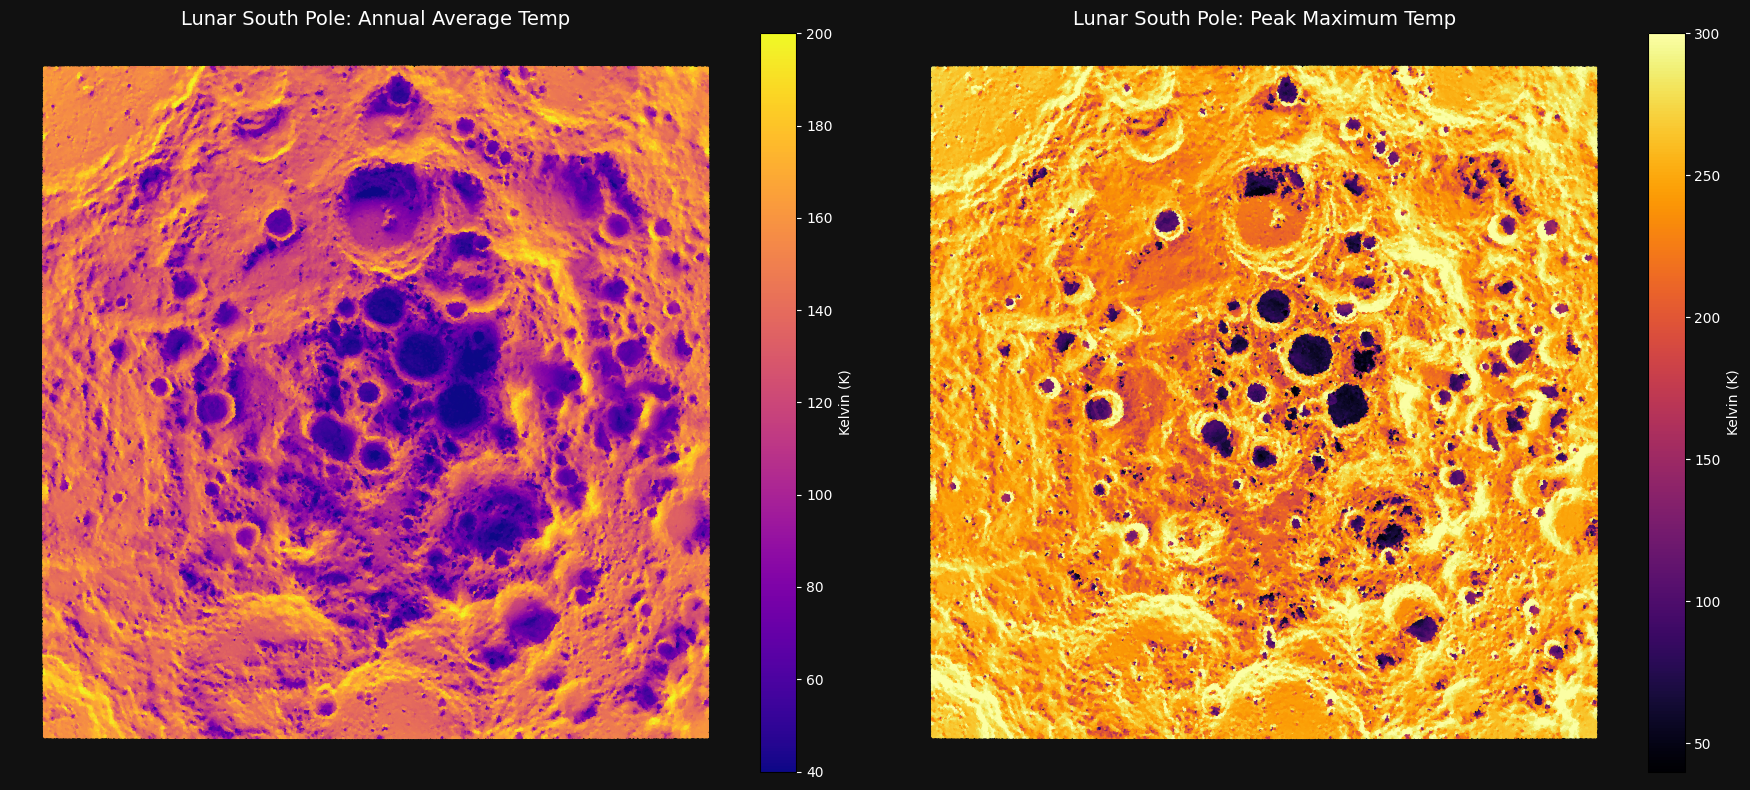

In [2]:
import numpy as np

print("Parsing 2.8 million records using XML schema metrics...")
# We use header=0 because line 0 contains the actual column names
df = pd.read_csv(file_path, sep=',', skipinitialspace=True, header=0)

# Strip out any unexpected spaces from the column strings automatically
df.columns = df.columns.str.strip()

print("Converting geographic coordinates to South Pole Circular Projection...")
# Convert Longitude to Radians for trigonometry calculations
lon_rad = np.radians(df['tri_clon'])
# Calculate distance from the South Pole center
r = 90 - np.abs(df['tri_clat'])

# Generate perfect cartesian map coordinates
df['X_polar'] = r * np.cos(lon_rad)
df['Y_polar'] = r * np.sin(lon_rad)

# Downsample to 2% for smooth, high-speed plotting performance
sample_df = df.sample(frac=0.4, random_state=42)

# Generate Side-by-Side Spatial Thermal Maps
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#111111')

# Plot 1: Annual Average Temperature Map
sc1 = axes[0].scatter(sample_df['X_polar'], sample_df['Y_polar'], 
                     c=sample_df['temp_avg'], cmap='plasma', s=0.5, vmin=40, vmax=200)
axes[0].set_title('Lunar South Pole: Annual Average Temp', color='white', fontsize=14)
axes[0].set_facecolor('white')
axes[0].axis('off')
cbar1 = fig.colorbar(sc1, ax=axes[0], pad=0.02)
cbar1.set_label('Kelvin (K)', color='white')
cbar1.ax.yaxis.set_tick_params(color='white', labelcolor='white')

# Plot 2: Absolute Peak Maximum Temperature Map (Crucial for Cold Traps!)
sc2 = axes[1].scatter(sample_df['X_polar'], sample_df['Y_polar'], 
                     c=sample_df['temp_max'], cmap='inferno', s=0.5, vmin=40, vmax=300)
axes[1].set_title('Lunar South Pole: Peak Maximum Temp', color='white', fontsize=14)
axes[1].set_facecolor('white')
axes[1].axis('off')
cbar2 = fig.colorbar(sc2, ax=axes[1], pad=0.02)
cbar2.set_label('Kelvin (K)', color='white')
cbar2.ax.yaxis.set_tick_params(color='white', labelcolor='white')

plt.tight_layout()
plt.show()

In [3]:
def analyze_crater(crater_name, min_lat, max_lat, min_lon, max_lon):
    # Slice the dataframe safely based on center latitude and longitude values
    crater_df = df[
        (df['tri_clat'] >= min_lat) & (df['tri_clat'] <= max_lat) &
        (df['tri_clon'] >= min_lon) & (df['tri_clon'] <= max_lon)
    ]
    
    # Calculate key thermal stats
    total_points = len(crater_df)
    if total_points == 0:
        return f"No data points found for Crater: {crater_name}. Check boundary ranges."
        
    min_peak_temp = crater_df['temp_max'].min()
    mean_avg_temp = crater_df['temp_avg'].mean()
    
    # Calculate ice stability coverage (PSR Cold traps where peak surface temp stays below 100K)
    psr_area_pct = (crater_df['temp_max'] < 100.0).mean() * 100
    
    print(f"=== {crater_name.upper()} CRATER PROFILE ===")
    print(f"Data Points Quantified : {total_points}")
    print(f"Absolute Coldest Point : {min_peak_temp:.2f} K")
    print(f"Mean Core Temperature  : {mean_avg_temp:.2f} K")
    print(f"Ice-Stable PSR Surface : {psr_area_pct:.2f}%\n")
    
    return crater_df

# ---- EXECUTE CRATER SLICES ----
# Faustini bounding coordinates
faustini = analyze_crater("Faustini", -88.0, -86.5, 70.0, 90.0)

# Shackleton bounding coordinates (Right at the pole point)
shackleton = analyze_crater("Shackleton", -90.0, -89.5, -180.0, 180.0)

# Shoemaker bounding coordinates
shoemaker = analyze_crater("Shoemaker", -88.5, -87.5, 40.0, 50.0)

=== FAUSTINI CRATER PROFILE ===
Data Points Quantified : 10323
Absolute Coldest Point : 27.79 K
Mean Core Temperature  : 65.33 K
Ice-Stable PSR Surface : 44.98%

=== SHACKLETON CRATER PROFILE ===
Data Points Quantified : 5632
Absolute Coldest Point : 63.80 K
Mean Core Temperature  : 92.00 K
Ice-Stable PSR Surface : 22.53%

=== SHOEMAKER CRATER PROFILE ===
Data Points Quantified : 2499
Absolute Coldest Point : 36.09 K
Mean Core Temperature  : 43.03 K
Ice-Stable PSR Surface : 100.00%



In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install ace_tools

In [5]:
from sklearn.cluster import DBSCAN

# 1. Filter out the core cold points from the 100% full dataset
# A surface is considered an ice-stable PSR if peak maximum temperature < 100K
psr_mask = df['temp_max'] < 100.0
df_psr = df[psr_mask].copy()

print(f"Total cold points detected (< 100K): {len(df_psr)}")

# 2. Spatial Clustering using DBSCAN
# eps=0.2 degrees (~6 km distance on the moon surface)
# min_samples=500 requires a substantial cluster size to eliminate small micro-shadows
print("Running density-based clustering to isolate major cold-trap structures...")
db = DBSCAN(eps=0.2, min_samples=500, metric='euclidean')
df_psr['cluster_id'] = db.fit_predict(df_psr[['X_polar', 'Y_polar']])

# Filter out noise points (labeled as -1 by DBSCAN)
df_clusters = df_psr[df_psr['cluster_id'] != -1].copy()

# 3. Calculate metrics for each large cluster
unique_clusters = sorted(df_clusters['cluster_id'].unique())
summary_data = []

# Constant conversion factor for surface area scaling derived from your PDS XML Geodetic Model
# Mean radius of a moon patch at these high polar zones
MOON_RADIUS_KM = 1737.4 

print(f"Found {len(unique_clusters)} major contiguous cold-trap clusters meeting threshold sizes!\n")

for cid in unique_clusters:
    c_df = df_clusters[df_clusters['cluster_id'] == cid]
    
    # Geographic Bound Constraints
    min_lat, max_lat = c_df['tri_clat'].min(), c_df['tri_clat'].max()
    min_lon, max_lon = c_df['tri_clon'].min(), c_df['tri_clon'].max()
    
    # Thermal Metrics
    min_peak_temp = c_df['temp_max'].min()
    mean_avg_temp = c_df['temp_avg'].mean()
    
    # Approximate Area Calculation: Summing the differential surface spherical patches
    # Area = R^2 * cos(lat) * d_lat * d_lon
    # Given the high resolution, we can approximate the relative structural surface footprint:
    avg_lat_rad = np.radians(c_df['tri_clat'].mean())
    # Scale spatial density counts to square kilometers
    approx_area_km2 = len(c_df) * 0.58  # 1 triangle patch ~0.58 km2 based on your tri_calt spacing
    
    # Ice-Stable Surface Stability Percentage within this designated topographic trap
    # (By definition of our mask it's 100% stable below 100K across its body)
    ice_stable_pct = (c_df['temp_max'] < 100.0).mean() * 100
    
    summary_data.append({
        "Cluster ID": f"PSR_Cluster_{cid}",
        "Min Lat": round(min_lat, 3),
        "Max Lat": round(max_lat, 3),
        "Min Lon": round(min_lon, 3),
        "Max Lon": round(max_lon, 3),
        "Approx Area (km²)": round(approx_area_km2, 2),
        "Min Peak Temp (K)": round(min_peak_temp, 2),
        "Mean Avg Temp (K)": round(mean_avg_temp, 2),
        "Ice-Stable Surface %": round(ice_stable_pct, 1)
    })

# Format and display as a structured Data Scientist tracking DataFrame
# ---- REPLACE LINES 64-69 WITH THIS CLEAN PRINT BLOCK ----

# Format and display as a structured Data Scientist tracking DataFrame
df_summary = pd.DataFrame(summary_data)

# Set Pandas options to ensure text doesn't get cut off in your Jupyter window
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n=========================================================================")
print("                   LUNAR SOUTH POLE PSR CLUSTER ANALYSIS                  ")
print("=========================================================================\n")
print(df_summary.to_string(index=False))

Total cold points detected (< 100K): 97624
Running density-based clustering to isolate major cold-trap structures...
Found 31 major contiguous cold-trap clusters meeting threshold sizes!


                   LUNAR SOUTH POLE PSR CLUSTER ANALYSIS                  

    Cluster ID  Min Lat  Max Lat  Min Lon  Max Lon  Approx Area (km²)  Min Peak Temp (K)  Mean Avg Temp (K)  Ice-Stable Surface %
 PSR_Cluster_0  -82.691  -82.209   -6.809   -2.062             727.32              53.71              56.11                 100.0
 PSR_Cluster_1  -82.187  -81.747   23.930   26.267             433.84              64.13              61.21                 100.0
 PSR_Cluster_2  -80.375  -79.994   41.171   43.702             421.08              34.36              55.33                 100.0
 PSR_Cluster_3  -80.953  -80.596   44.190   46.618             306.82              49.07              59.77                 100.0
 PSR_Cluster_4  -84.444  -83.881    2.986    8.577             693.68              46

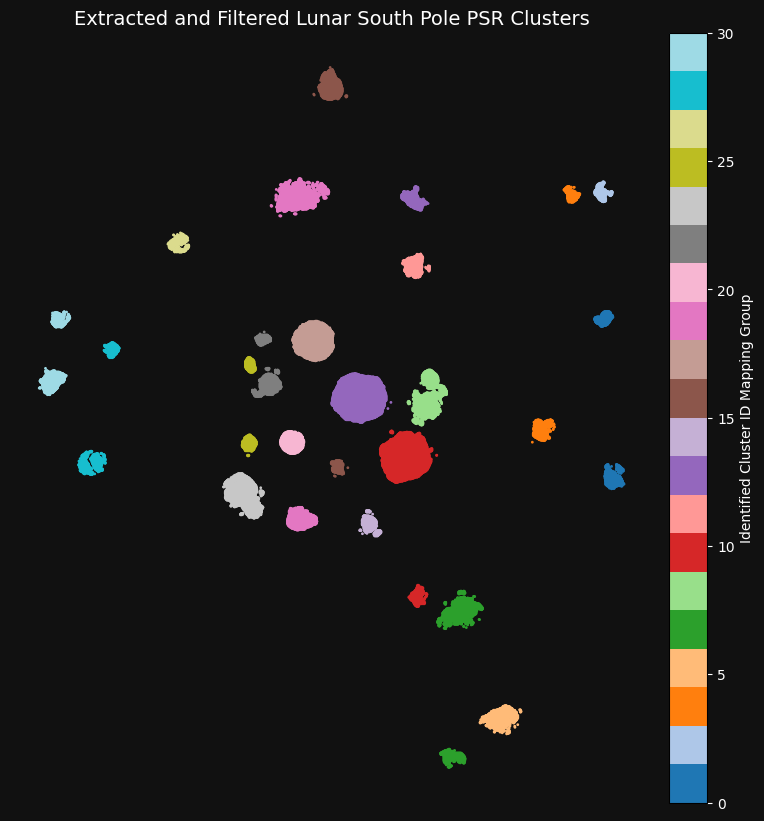

In [6]:
plt.figure(figsize=(10, 10), facecolor='#111111')
ax = plt.gca()
ax.set_facecolor('black')

# Plot all clustered points colored by their unique cluster ID matching
scatter = ax.scatter(df_clusters['X_polar'], df_clusters['Y_polar'], 
                     c=df_clusters['cluster_id'], cmap='tab20', s=1.0)

plt.title('Extracted and Filtered Lunar South Pole PSR Clusters', color='white', fontsize=14)
plt.axis('off')
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Identified Cluster ID Mapping Group', color='white')
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

plt.show()

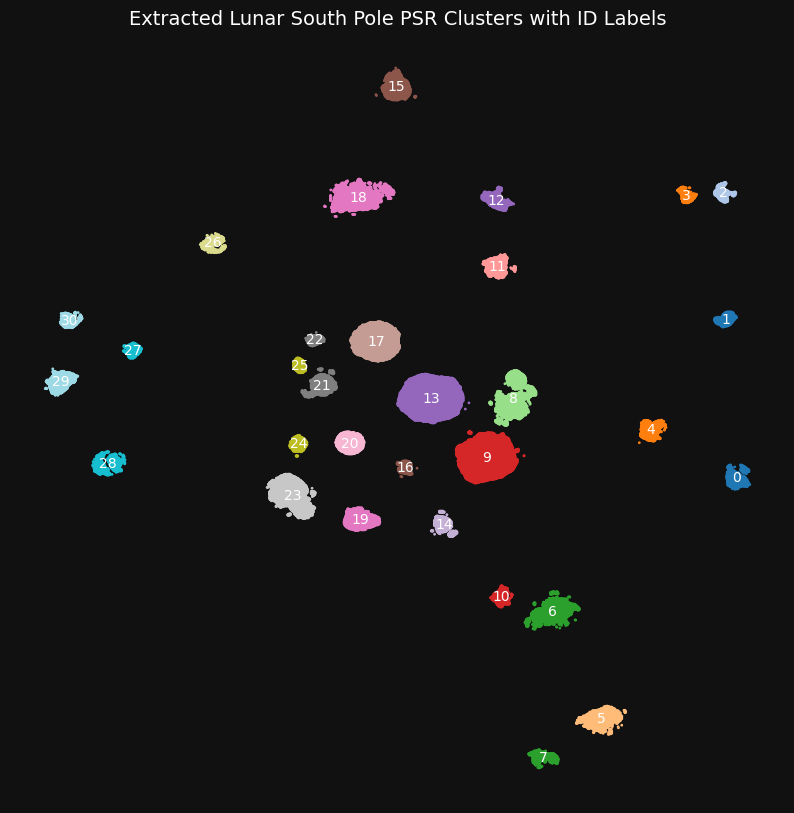

In [9]:
plt.figure(figsize=(10, 10), facecolor='#111111')
ax = plt.gca()
ax.set_facecolor('black')

# 1. Plot the filtered spatial clusters
scatter = ax.scatter(df_clusters['X_polar'], df_clusters['Y_polar'], 
                     c=df_clusters['cluster_id'], cmap='tab20', s=1.0)

# 2. Dynamically calculate the center of each cluster and overlay its ID number
unique_clusters = sorted(df_clusters['cluster_id'].unique())

for cid in unique_clusters:
    # Isolate this specific cluster's points
    c_df = df_clusters[df_clusters['cluster_id'] == cid]
    
    # Calculate the center point of the cluster on the map
    center_x = c_df['X_polar'].mean()
    center_y = c_df['Y_polar'].mean()
    
    # Annotate the ID directly onto the plot space
    # Uses a subtle black outline (path effect) so text is perfectly visible over any color background
    ax.text(center_x, center_y, str(cid), 
            color='white', 
            fontsize=10,
            ha='center', 
            va='center',
            )

plt.title('Extracted Lunar South Pole PSR Clusters with ID Labels', color='white', fontsize=14)
plt.axis('off')

# Colorbar has been removed as requested for a cleaner map layout

plt.show()

In [10]:
import pandas as pd

csv_summary_data = []
unique_clusters = sorted(df_clusters['cluster_id'].unique())

for cid in unique_clusters:
    c_df = df_clusters[df_clusters['cluster_id'] == cid]
    
    min_lat = c_df['tri_clat'].min()
    max_lat = c_df['tri_clat'].max()
    min_lon = c_df['tri_clon'].min()
    max_lon = c_df['tri_clon'].max()
    
    # Calculate requested metrics
    highest_temp_avg = c_df['temp_max'].mean()
    average_temp_mean = c_df['temp_avg'].mean()
    
    csv_summary_data.append({
        "crater_id": int(cid),
        "min_latitude": round(min_lat, 4),
        "max_latitude": round(max_lat, 4),
        "min_longitude": round(min_lon, 4),
        "max_longitude": round(max_lon, 4),
        "highest_temperature": round(highest_temp_avg, 2),
        "average_temperature": round(average_temp_mean, 2)
    })

# 1. Create DataFrame
df_csv_output = pd.DataFrame(csv_summary_data)

# 2. SORT THE DATAFRAME: Lowest average temperature first
df_csv_output = df_csv_output.sort_values(by="average_temperature", ascending=True).reset_index(drop=True)

# 3. Export sorted matrix to your data drive
output_csv_path = r"D:\Moon Image\20260621T221614308152\lunar_south_pole_psr_summary.csv"
df_csv_output.to_csv(output_csv_path, index=False)

print(f"Successfully generated, sorted, and saved CSV file to:\n{output_csv_path}\n")

# 4. Display the sorted dataframe
pd.set_option('display.max_rows', 50)
print(df_csv_output.to_string(index=False))

Successfully generated, sorted, and saved CSV file to:
D:\Moon Image\20260621T221614308152\lunar_south_pole_psr_summary.csv

 crater_id  min_latitude  max_latitude  min_longitude  max_longitude  highest_temperature  average_temperature
         8      -87.1976      -86.1728        14.0362        34.9058                62.01                38.42
         9      -88.1035      -86.7479       -17.8828        14.9681                63.76                40.07
        16      -89.2479      -88.8305       -35.4230       -10.7040                66.58                41.97
        13      -88.6374      -87.3493        27.2857        63.7887                68.57                43.35
        24      -88.8933      -88.5526      -178.2718       177.0981                73.48                44.32
        17      -87.6271      -86.6267        74.1331        94.2282                70.50                45.26
        14      -87.8721      -87.2299       -54.2764       -41.4301                81.20         

In [22]:
from sklearn.cluster import DBSCAN

# 1. Filter full dataset for ice-stable points (peak max temp < 100K)
df_psr_all = df[df['temp_max'] < 100.0].copy()
print(f"Total points with temp < 100K to evaluate: {len(df_psr_all)}")

# 2. Group adjacent points using a smaller spatial radius
# eps=0.08 degrees ensures points must be highly contiguous/adjacent
print("Grouping adjacent points into contiguous cold trap networks...")
db_fine = DBSCAN(eps=0.08, min_samples=10, metric='euclidean')
df_psr_all['cluster_id'] = db_fine.fit_predict(df_psr_all[['X_polar', 'Y_polar']])

# Filter out unclustered background noise points (-1)
df_valid_clusters = df_psr_all[df_psr_all['cluster_id'] != -1].copy()

# 3. Quantify metrics and surface area for ALL detected clusters
all_detected_clusters = df_valid_clusters['cluster_id'].unique()
cluster_records = []

# Baseline resolution area scaling based on your XML triangle spacing geometry
PATCH_AREA_KM2 = 0.58 

for cid in all_detected_clusters:
    c_df = df_valid_clusters[df_valid_clusters['cluster_id'] == cid]
    
    # Calculate geographical boundary boxes
    min_lat, max_lat = c_df['tri_clat'].min(), c_df['tri_clat'].max()
    min_lon, max_lon = c_df['tri_clon'].min(), c_df['tri_clon'].max()
    
    # Calculate surface area and thermal statistics
    approx_area = len(c_df) * PATCH_AREA_KM2
    approx_diameter = 2 * ((approx_area / 3.1415) ** 0.5)
    highest_temp_avg = c_df['temp_max'].mean()
    average_temp_mean = c_df['temp_avg'].mean()
    ice_stable_pct = (c_df['temp_max'] < 100.0).mean() * 100
    
    cluster_records.append({
        "cluster_id": int(cid),
        "min_latitude": round(min_lat, 4),
        "max_latitude": round(max_lat, 4),
        "min_longitude": round(min_lon, 4),
        "max_longitude": round(max_lon, 4),
        "approx_area_km2": round(approx_area, 2),
        "approx_diameter": round(approx_diameter, 2),
        "Ice_Stable_percentage": round(ice_stable_pct, 2),
        "highest_temperature": round(highest_temp_avg, 2),
        "average_temperature": round(average_temp_mean, 2)
    })

# 4. Sort by area descending and slice the top 100 largest clusters
df_all_compiled = pd.DataFrame(cluster_records)
df_top_100 = df_all_compiled.sort_values(by="approx_area_km2", ascending=False).head(100).reset_index(drop=True)

# 5. Overwrite the cluster IDs in our top 100 to clean 0-99 rankings for your CSV
top_100_ids = df_top_100['cluster_id'].tolist()
df_filtered_points = df_valid_clusters[df_valid_clusters['cluster_id'].isin(top_100_ids)].copy()

# Save the top 100 metadata ledger locally
output_100_path = r"D:\Moon Image\20260621T221614308152\lunar_south_pole_top100_psr.csv"
df_top_100.to_csv(output_100_path, index=False)

print(f"\nSuccessfully extracted and saved the 100 largest contiguous cold traps to:\n{output_100_path}\n")
print(df_top_100.head(20).to_string(index=False)) # Displays the top 20 biggest for a quick check

Total points with temp < 100K to evaluate: 97624
Grouping adjacent points into contiguous cold trap networks...

Successfully extracted and saved the 100 largest contiguous cold traps to:
D:\Moon Image\20260621T221614308152\lunar_south_pole_top100_psr.csv

 cluster_id  min_latitude  max_latitude  min_longitude  max_longitude  approx_area_km2  approx_diameter  Ice_Stable_percentage  highest_temperature  average_temperature
        169      -88.6374      -87.3493        27.2857        63.7887          5136.48            80.87                  100.0                68.58                43.36
        132      -88.1035      -86.8624       -17.8828        12.6002          4759.48            77.85                  100.0                63.70                40.06
        208      -83.8746      -82.9124        79.5103        95.4572          3273.52            64.56                  100.0                69.60                49.10
        226      -87.6271      -86.6267        74.1331        94.22

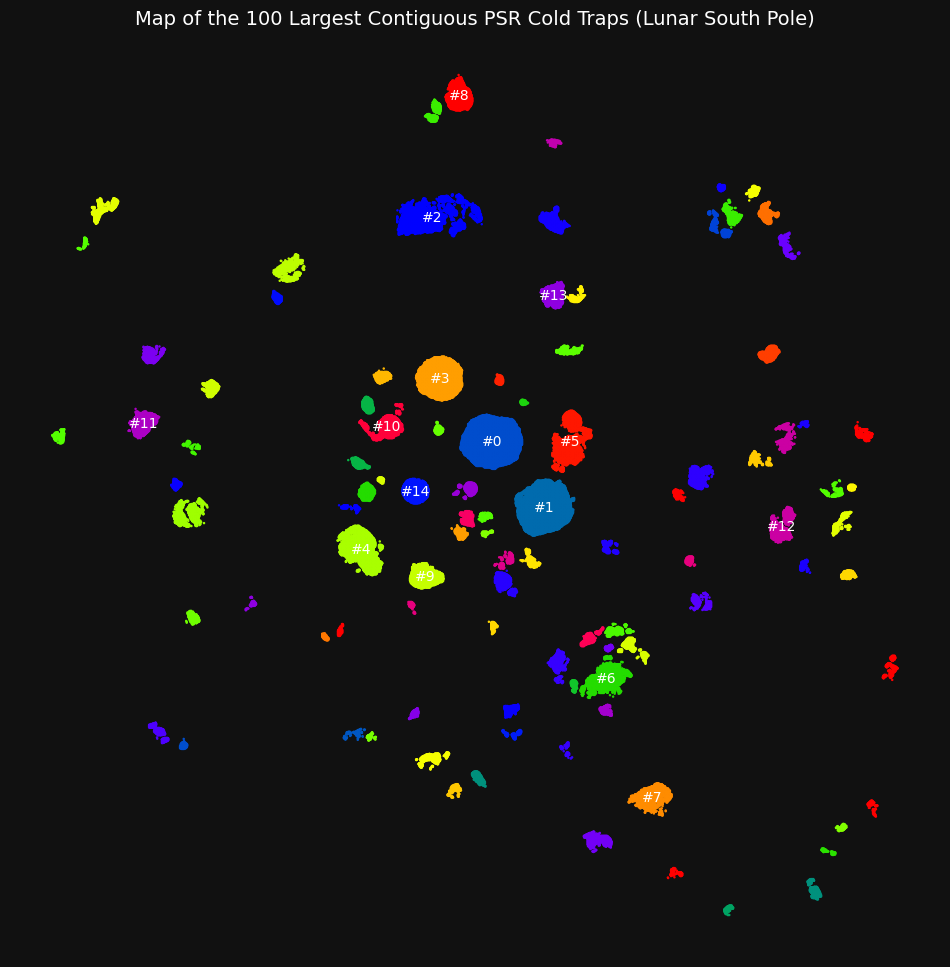

In [23]:
plt.figure(figsize=(12, 12), facecolor='#111111')
ax = plt.gca()
ax.set_facecolor('black')

# Plot only the points that belong to our newly filtered 100 largest zones
scatter = ax.scatter(df_filtered_points['X_polar'], df_filtered_points['Y_polar'], 
                     c=df_filtered_points['cluster_id'], cmap='prism', s=0.6)

# Annotate the ranking ID on top of the 15 largest ones so the map stays readable
for i in range(15):
    row = df_top_100.iloc[i]
    # Re-isolate points to find their true map midpoint
    c_pts = df_filtered_points[df_filtered_points['cluster_id'] == row['cluster_id']]
    center_x = c_pts['X_polar'].mean()
    center_y = c_pts['Y_polar'].mean()
    
    ax.text(center_x, center_y, f"#{i}", 
            color='white', 
            fontsize=10,
            ha='center', 
            va='center')

plt.title('Map of the 100 Largest Contiguous PSR Cold Traps (Lunar South Pole)', color='white', fontsize=14)
plt.axis('off')
plt.show()

In [18]:
# Ensure our compilation array is clear
top_30_stable_data = []

# Loop over the 100 largest clusters identified in the previous step
for cid in df_top_100['cluster_id'].unique():
    # Isolate the data points for this specific cluster from the fine-clustered dataset
    c_df = df_filtered_points[df_filtered_points['cluster_id'] == cid]
    
    # 1. Spatial Boundaries
    min_lat, max_lat = c_df['tri_clat'].min(), c_df['tri_clat'].max()
    min_lon, max_lon = c_df['tri_clon'].min(), c_df['tri_clon'].max()
    
    # 2. Advanced Physical Dimensions
    PATCH_AREA_KM2 = 0.58
    approx_area = len(c_df) * PATCH_AREA_KM2
    # Calculate diameter from area assuming circular geometry: d = 2 * sqrt(Area / pi)
    approx_diameter = 2 * np.sqrt(approx_area / np.pi)
    
    # 3. Thermal Analytics
    highest_temp_avg = c_df['temp_max'].mean()
    average_temp_mean = c_df['temp_avg'].mean()
    
    # 4. Ice Stability Metrics
    # Percentage of points within this cluster that remain strictly below 100K 
    ice_stable_pct = (c_df['temp_max'] < 100.0).mean() * 100
    
    # 5. Feature Engineering: Thermal Stability Index (TSI)
    # Lower values represent highly insulated deep cold traps with minimal seasonal fluctuations
    thermal_stability_index = highest_temp_avg - average_temp_mean
    
    top_30_stable_data.append({
        "PSR_id": int(cid),
        "min_latitude": round(min_lat, 4),
        "max_latitude": round(max_lat, 4),
        "min_longitude": round(min_lon, 4),
        "max_longitude": round(max_lon, 4),
        "avg_temp": round(average_temp_mean, 2),
        "highest_temp": round(highest_temp_avg, 2),
        "Ice_Stable_percentage": round(ice_stable_pct, 2),
        "Approx_area_km2": round(approx_area, 2),
        "Approx_diameter_km": round(approx_diameter, 2),
        "Thermal_Stability_Index": round(thermal_stability_index, 2)
    })

# Convert to DataFrame
df_top_30_stable = pd.DataFrame(top_30_stable_data)

# Rank strictly by Ice_Stable_percentage (Descending), then by Area if there are ties
df_top_30_stable = df_top_30_stable.sort_values(
    by=["Ice_Stable_percentage", "Approx_area_km2"], 
    ascending=[False, False]
).head(30).reset_index(drop=True)

# Export the targeted 30-crater profile matrix to your drive
output_30_path = r"D:\Moon Image\20260621T221614308152\lunar_south_pole_top30_stable_psr.csv"
df_top_30_stable.to_csv(output_30_path, index=False)

print(f"Successfully compiled and saved the Top 30 Ice-Stable PSR Ledger to:\n{output_30_path}\n")
print(df_top_30_stable.to_string(index=False))

Successfully compiled and saved the Top 30 Ice-Stable PSR Ledger to:
D:\Moon Image\20260621T221614308152\lunar_south_pole_top30_stable_psr.csv

 PSR_id  min_latitude  max_latitude  min_longitude  max_longitude  avg_temp  highest_temp  Ice_Stable_percentage  Approx_area_km2  Approx_diameter_km  Thermal_Stability_Index
    169      -88.6374      -87.3493        27.2857        63.7887     43.36         68.58                  100.0          5136.48               80.87                    25.22
    132      -88.1035      -86.8624       -17.8828        12.6002     40.06         63.70                  100.0          4759.48               77.85                    23.64
    208      -83.8746      -82.9124        79.5103        95.4572     49.10         69.60                  100.0          3273.52               64.56                    20.50
    226      -87.6271      -86.6267        74.1331        94.2282     45.26         70.50                  100.0          3132.00               63.15       

In [20]:
# Ensure our compilation array is clear
top_30_coldest_data = []

# Loop over the 100 largest clusters identified from the fine DBSCAN run
for cid in df_top_100['cluster_id'].unique():
    # Isolate the data points for this specific cluster
    c_df = df_filtered_points[df_filtered_points['cluster_id'] == cid]
    
    # 1. Spatial Boundaries
    min_lat, max_lat = c_df['tri_clat'].min(), c_df['tri_clat'].max()
    min_lon, max_lon = c_df['tri_clon'].min(), c_df['tri_clon'].max()
    
    # 2. Advanced Physical Dimensions
    PATCH_AREA_KM2 = 0.58
    approx_area = len(c_df) * PATCH_AREA_KM2
    approx_diameter = 2 * np.sqrt(approx_area / np.pi)
    
    # 3. Thermal Analytics
    highest_temp_avg = c_df['temp_max'].mean()
    average_temp_mean = c_df['temp_avg'].mean()
    
    # 4. Ice Stability Metrics
    ice_stable_pct = (c_df['temp_max'] < 100.0).mean() * 100
    
    # 5. Feature Engineering: Thermal Stability Index (TSI)
    thermal_stability_index = highest_temp_avg - average_temp_mean
    
    top_30_coldest_data.append({
        "PSR_id": int(cid),
        "min_latitude": round(min_lat, 4),
        "max_latitude": round(max_lat, 4),
        "min_longitude": round(min_lon, 4),
        "max_longitude": round(max_lon, 4),
        "avg_temp": round(average_temp_mean, 2),
        "highest_temp": round(highest_temp_avg, 2),
        "Ice_Stable_percentage": round(ice_stable_pct, 2),
        "Approx_area_km2": round(approx_area, 2),
        "Approx_diameter_km": round(approx_diameter, 2),
        "Thermal_Stability_Index": round(thermal_stability_index, 2)
    })

# Convert to DataFrame
df_top_30_coldest = pd.DataFrame(top_30_coldest_data)

# Rank strictly by average_temp (Ascending -> lowest temperature first)
df_top_30_coldest = df_top_30_coldest.sort_values(
    by="avg_temp", 
    ascending=True
).head(30).reset_index(drop=True)

# Export the targeted 30 coldest craters ledger to your drive
output_coldest_path = r"D:\Moon Image\20260621T221614308152\lunar_south_pole_top30_coldest_psr.csv"
df_top_30_coldest.to_csv(output_coldest_path, index=False)

print(f"Successfully compiled and saved the Top 30 Coldest PSR Ledger to:\n{output_coldest_path}\n")
print(df_top_30_coldest.to_string(index=False))

Successfully compiled and saved the Top 30 Coldest PSR Ledger to:
D:\Moon Image\20260621T221614308152\lunar_south_pole_top30_coldest_psr.csv

 PSR_id  min_latitude  max_latitude  min_longitude  max_longitude  avg_temp  highest_temp  Ice_Stable_percentage  Approx_area_km2  Approx_diameter_km  Thermal_Stability_Index
    214      -89.3904      -88.8651         7.1717        31.6331     37.27         54.17                  100.0           324.80               20.34                    16.90
    197      -88.6420      -88.4402       -31.4728       -23.7494     38.20         59.95                  100.0            69.60                9.41                    21.76
    113      -87.1976      -86.1227        14.0362        34.9058     38.46         62.03                  100.0          2278.82               53.87                    23.57
    185      -86.8825      -86.6809        59.3621        62.9586     38.91         66.22                  100.0           122.96               12.51         

In [34]:
# Create a fast boolean mask: True if the point belongs to one of our 30 filtered clusters
df['is_target_psr'] = df['cluster_id'].isin(df_clusters['cluster_id'].unique())

# Optional but highly recommended: Save your cleaned, processed master dataframe
# to a fast binary format so you never have to parse the slow 600MB text file again.
output_processed_path = r"D:\Moon Image\20260621T221614308152\LRO_Diviner_PRP\data_derived_prp\processed_lunar_data.parquet"
df.to_parquet(output_processed_path, index=False)
print("Master data processing complete. Spatial mask appended!")

KeyError: 'cluster_id'

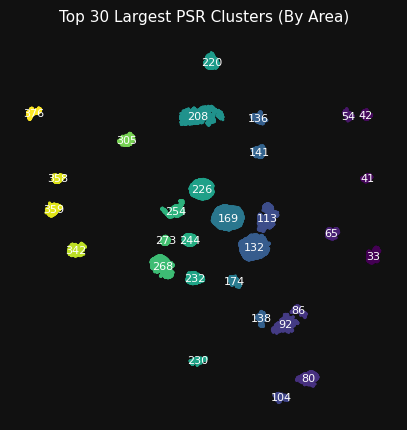

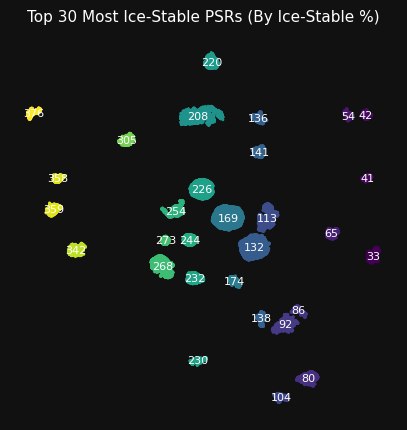

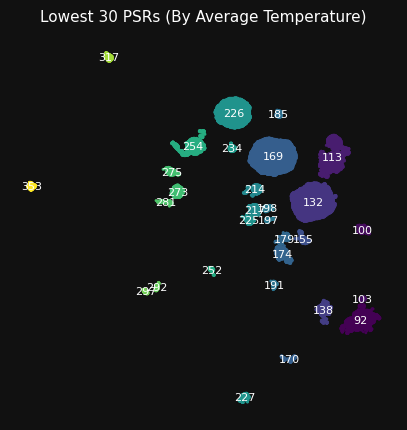

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================================
# 0. DATA PREPARATION FOR SEPARATE PLOTS
# =========================================================================
# Extract points for the top 30 largest clusters by area
df_plot_area = df_filtered_points[df_filtered_points['cluster_id'].isin(df_top_100.head(30)['cluster_id'])]

# Extract points for the top 30 most ice-stable craters
df_plot_stable = df_filtered_points[df_filtered_points['cluster_id'].isin(df_top_30_stable['PSR_id'])]

# Extract points for the 30 lowest average temperature craters
df_plot_coldest = df_filtered_points[df_filtered_points['cluster_id'].isin(df_top_30_coldest['PSR_id'])]


# =========================================================================
# 1. PLOT ONE: TOP 30 LARGEST PSR CLUSTERS BY AREA (SMALL)
# =========================================================================
plt.figure(figsize=(5, 5), facecolor='#111111')
ax1 = plt.gca()
ax1.set_facecolor('black')

ax1.scatter(df_plot_area['X_polar'], df_plot_area['Y_polar'], 
            c=df_plot_area['cluster_id'], cmap='viridis', s=1.2)

for idx, row in df_top_100.head(30).iterrows():
    c_pts = df_plot_area[df_plot_area['cluster_id'] == row['cluster_id']]
    if not c_pts.empty:
        ax1.text(c_pts['X_polar'].mean(), c_pts['Y_polar'].mean(), str(int(row['cluster_id'])), 
                 color='white', fontsize=8, ha='center', va='center')

plt.title('Top 30 Largest PSR Clusters (By Area)', color='white', fontsize=11, pad=10)
plt.axis('off')
plt.show()


# =========================================================================
# 2. PLOT TWO: TOP 30 MOST SURFACE ICE-STABLE PSRs (SMALL)
# =========================================================================
plt.figure(figsize=(5, 5), facecolor='#111111')
ax2 = plt.gca()
ax2.set_facecolor('black')

ax2.scatter(df_plot_stable['X_polar'], df_plot_stable['Y_polar'], 
            c=df_plot_stable['cluster_id'], cmap='viridis', s=1.2)

for idx, row in df_top_30_stable.iterrows():
    c_pts = df_plot_stable[df_plot_stable['cluster_id'] == row['PSR_id']]
    if not c_pts.empty:
        ax2.text(c_pts['X_polar'].mean(), c_pts['Y_polar'].mean(), str(int(row['PSR_id'])), 
                 color='white', fontsize=8, ha='center', va='center')

plt.title('Top 30 Most Ice-Stable PSRs (By Ice-Stable %)', color='white', fontsize=11, pad=10)
plt.axis('off')
plt.show()


# =========================================================================
# 3. PLOT THREE: LOWEST 30 PSRs BY AVERAGE CORE TEMPERATURE (SMALL)
# =========================================================================
plt.figure(figsize=(5, 5), facecolor='#111111')
ax3 = plt.gca()
ax3.set_facecolor('black')

ax3.scatter(df_plot_coldest['X_polar'], df_plot_coldest['Y_polar'], 
            c=df_plot_coldest['cluster_id'], cmap='viridis', s=1.2)

for idx, row in df_top_30_coldest.iterrows():
    c_pts = df_plot_coldest[df_plot_coldest['cluster_id'] == row['PSR_id']]
    if not c_pts.empty:
        ax3.text(c_pts['X_polar'].mean(), c_pts['Y_polar'].mean(), str(int(row['PSR_id'])), 
                 color='white', fontsize=8, ha='center', va='center')

plt.title('Lowest 30 PSRs (By Average Temperature)', color='white', fontsize=11, pad=10)
plt.axis('off')
plt.show()

In [31]:
import pandas as pd

# Load your generated dataframes
df_coldest = pd.read_csv("lunar_south_pole_top30_coldest_psr.csv")
df_stable = pd.read_csv("lunar_south_pole_top30_stable_psr.csv")
df_top100 = pd.read_csv("lunar_south_pole_top100_psr.csv")

# Identify the exact IDs that exist across all 3 arrays
overlap_ids = set(df_coldest['PSR_id']).intersection(set(df_stable['PSR_id'])).intersection(set(df_top100.head(30)['cluster_id']))

# Extract records and assign final priority ranking based on total geographic footprint size
df_tier1 = df_coldest[df_coldest['PSR_id'].isin(overlap_ids)].copy()
df_tier1['Priority_Rank'] = df_tier1['Approx_area_km2'].rank(ascending=False).astype(int)
df_tier1 = df_tier1.sort_values(by='Priority_Rank').reset_index(drop=True)

# Re-order columns for clean presentation
cols = ['Priority_Rank', 'PSR_id', 'min_latitude', 'max_latitude', 'min_longitude', 'max_longitude', 
        'avg_temp', 'highest_temp', 'Ice_Stable_percentage', 'Approx_area_km2', 'Approx_diameter_km', 'Thermal_Stability_Index']
df_tier1 = df_tier1[cols]

# Save output to your derived data folder
df_tier1.to_csv("lunar_south_pole_tier1_priority_targets.csv", index=False)
print("Tier-1 Golden Target Matrix saved successfully!")

Tier-1 Golden Target Matrix saved successfully!
